# 1. 20~23년 4개년 데이터 병합

In [15]:
import pandas as pd

# Set pandas display options
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 100)        # Set the display width to 1000 characters
pd.set_option('display.max_colwidth', None) # Allow the full content of each column to be displayed

In [16]:
import pyreadstat
df20, meta20 = pyreadstat.read_sas7bdat('hn20_all.sas7bdat')

In [17]:
var_label = meta20.column_names_to_labels

In [18]:
import pyreadstat
df21, meta21 = pyreadstat.read_sas7bdat('hn21_all.sas7bdat')

In [19]:
import pyreadstat
df22, meta22 = pyreadstat.read_sas7bdat('hn22_all.sas7bdat')

In [20]:
import pyreadstat
df23, meta23 = pyreadstat.read_sas7bdat('hn23_all.sas7bdat')

# 1-1. 변수 레이블 추출

In [21]:
print("\n=== 변수 레이블 ===")
for name, label in zip(meta20.column_names, meta20.column_labels):
    print(f"{name}: {label}")


=== 변수 레이블 ===
mod_d: 최종 DB 수정일
ID: 개인아이디
ID_fam: 가구 아이디
year: 조사연도
region: 시도
town_t: 동읍면
apt_t: 주택유형
psu: 조사구번호
sex: 성별
age: 만나이
age_month: 월령
incm: 소득4분위수(개인)
ho_incm: 소득4분위수(가구)
incm5: 소득5분위수(개인)
ho_incm5: 소득5분위수(가구)
edu: 교육수준 재분류 코드
occp: 직업재분류 및 실업/비경제활동인구상태 코드
wt_hs: 가구조사 가중치
wt_itvex: 건강설문,검진조사 가중치
wt_oe: 구강검진검사 가중치
wt_ntr: 영양조사 가중치
wt_tot: 건강설문,검진,영양조사 가중치
wt_oent: 구강검진,영양 가중치
kstrata: 분산추정 층
cfam: 가구원수
genertn: 가구세대구성코드
allownc: 기초생활수급 여부
house: 주택소유여부
live_t: 주택형태
ainc_unit1: 가구총소득(개방형): 소득단위
ainc_1: 가구총소득(개방형): 소득액
ainc: 월평균 가구총소득
marri_1: 결혼여부
marri_2: 결혼상태
fam_rela: 가구주와의 관계
tins: 건강보험종류
npins: 민간의료보험가입여부
ID_F: 아버지 아이디
ID_M: 어머니 아이디
D_1_1: 주관적 건강인지
D_2_1: 최근2주간 몸이 불편했던 경험 유무
D_2_wk: 최근2주간 불편감일수
DI1_dg: 고혈압 의사진단 여부
DI1_ag: 고혈압 진단시기
DI1_pr: 고혈압 현재 유병 여부
DI1_pt: 고혈압 치료
DI1_2: 혈압조절제 복용
DI2_dg: 이상지질혈증 의사진단 여부
DI2_ag: 이상지질혈증 진단시기
DI2_pr: 이상지질혈증 현재 유병 여부
DI2_pt: 이상지질혈증 치료
DI2_2: 이상지질혈증 약복용
DI3_dg: 뇌졸중 의사진단 여부
DI3_ag: 뇌졸중 진단시기
DI3_pr: 뇌졸중 현재 유병 여부
DI3_pt: 뇌졸중 치료
DI3_2: 뇌졸중 후유증
D

### 종속변수: 당뇨병 유병여부(HE_DM_HbA1c) (1=정상 / 3=당뇨병)

### 종속변수: 고혈압 유병여부(HE_HP) 1=정상 / 4=고혈압)

### 종속변수: 이상지질혈증(HE_HCHOL) 0=정상 / 1=고콜레스테롤혈증)

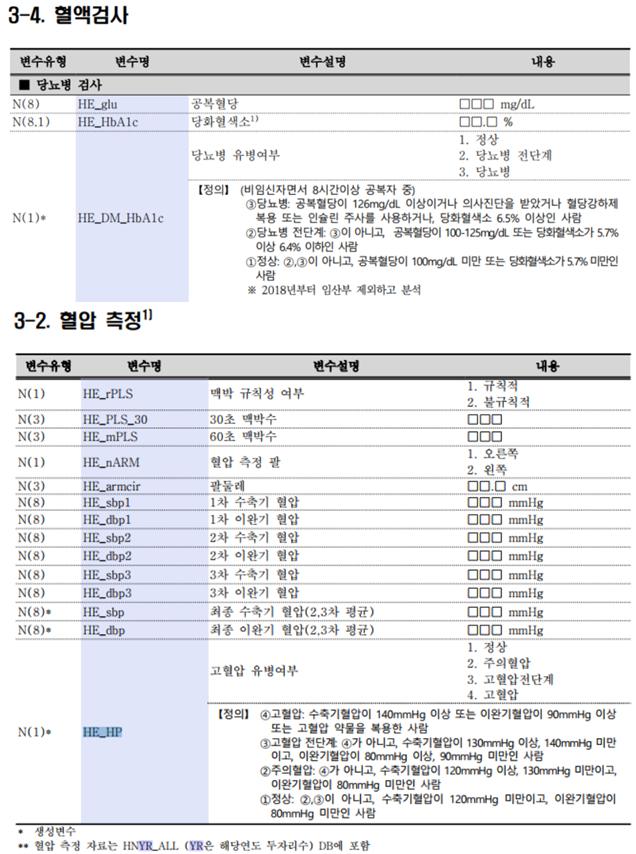

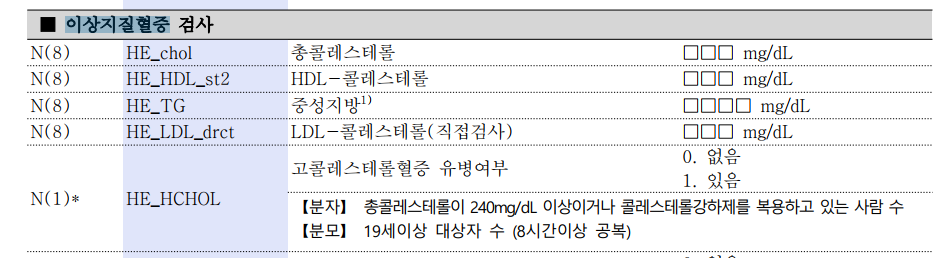

In [22]:
# 1. 식별 및 기본 정보 (Key Variables)
key = [
    'ID',             # 개인 아이디
    'sex',            # 성별 (1:남, 2:여)
    'age'             # 만나이
]

# 2. 범주형 변수 (Categorical Columns): 생활습관, 가족력, 약물복용 등
# 사용자님이 제공하신 리스트에 가족력 및 약물복용 변수를 추가했습니다.
cat_col = [
    'HE_obe',         # 비만 유병여부(19세이상)
    'BO1_1',          # 1년간 체중 변화 여부
    'BO1_2',          # 1년간 체중 감소량
    'BO1_3',          # 1년간 체중 증가량
    'BD1_11',         # 1년간 음주 빈도
    'BD2_1',          # 한번에 마시는 음주량
    'BS3_1',          # 현재 일반담배 흡연 여부
    'BE3_71',         # 고강도 신체활동 여부(일)
    'BE3_75',         # 고강도 신체활동 여부(여가)
    'BE3_81',         # 중강도 신체활동 여부(일)
    'BE3_91',         # 신체활동 여부(장소이동)
    'pa_aerobic',     # 유산소 신체활동 실천율
    'L_BR_FQ',        # 아침식사 빈도
    'BP1',            # 평소 스트레스 인지 정도
    'mh_stress',      # 스트레스 인지율
    'incm',           # 소득 4분위수(개인)
    'ho_incm',        # 소득 4분위수(가구)
    'edu',            # 교육수준 재분류 코드
    'BH1',            # 건강검진 수진 여부
    # --- 가족력 및 치료 이력 추가 ---
    'HE_HPfh1',       # 고혈압 가족력(부)
    'HE_HPfh2',       # 고혈압 가족력(모)
    'HE_DMfh1',       # 당뇨병 가족력(부)
    'HE_DMfh2',       # 당뇨병 가족력(모)
    'HE_HLfh1',       # 고지혈증 가족력(부)
    'HE_HLfh2',       # 고지혈증 가족력(모)
    'DI1_2',          # 혈압조절제 복용 여부
    'DE1_32',         # 당뇨병약 복용 여부
    'DI2_2'           # 이상지질혈증 약복용 여부
]

# 3. 수치형 변수 (Numerical Columns): 검사 결과 수치
# 소견서 작성을 위한 실제 바이탈 및 혈액검사 결과값입니다.
num_col = [
    'HE_sbp',         # 최종 수축기 혈압
    'HE_dbp',         # 최종 이완기 혈압
    'HE_wc',          # 허리둘레
    'HE_BMI',         # 체질량지수
    'HE_glu',         # 공복혈당
    'HE_HbA1c',       # 당화혈색소
    'HE_chol',        # 총콜레스테롤
    'HE_HDL_st2',     # HDL-콜레스테롤
    'HE_TG',          # 중성지방
    'HE_LDL_drct'      # LDL-콜레스테롤(직접검사)
]

# 4. 종속 변수 (Target Columns): 3대 성인병 유병 여부
target_col = [
    'HE_DM_HbA1c',    # 당뇨병 유병여부 (1=정상 / 3=당뇨병)
    'HE_HP',          # 고혈압 유병여부 (1=정상 / 4=고혈압)
    'HE_HCHOL'        # 고콜레스테롤혈증 유병여부 (0=정상 / 1=고콜레스테롤혈증)
]

# 전체 변수 통합
all_vars = key + cat_col + num_col + target_col

# 1-2. 선정 변수로 데이터 필터

In [23]:
df20_sel = df20[all_vars].copy()

In [24]:
df21_sel = df21[all_vars].copy()

In [25]:
df22_sel = df22[all_vars].copy()

In [26]:
df23_sel = df23[all_vars].copy()

In [27]:
df_total = pd.concat([df20_sel, df21_sel, df22_sel, df23_sel], axis=0).reset_index(drop=True).copy()

In [28]:
df_total

,ID,sex,age,HE_obe,BO1_1,BO1_2,BO1_3,BD1_11,BD2_1,BS3_1,BE3_71,BE3_75,BE3_81,BE3_91,pa_aerobic,L_BR_FQ,BP1,mh_stress,incm,ho_incm,edu,BH1,HE_HPfh1,HE_HPfh2,HE_DMfh1,HE_DMfh2,HE_HLfh1,HE_HLfh2,DI1_2,DE1_32,DI2_2,HE_sbp,HE_dbp,HE_wc,HE_BMI,HE_glu,HE_HbA1c,HE_chol,HE_HDL_st2,HE_TG,HE_LDL_drct,HE_DM_HbA1c,HE_HP,HE_HCHOL
0,A801169401,1.0,39.0,3.0,2.0,1.0,8.0,3.0,3.0,3.0,2.0,2.0,2.0,1.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,8.0,116.0,79.0,85.8,24.185489,84.0,5.5,150.0,44.0,73.0,NaN,1.0,1.0,0.0
1,A801169402,2.0,39.0,1.0,1.0,8.0,8.0,1.0,8.0,8.0,2.0,2.0,2.0,2.0,0.0,4.0,3.0,0.0,1.0,2.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,8.0,96.0,64.0,68.0,17.935939,89.0,5.3,187.0,65.0,65.0,NaN,1.0,1.0,0.0
2,A801169403,1.0,10.0,NaN,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,1.0,8.0,NaN,1.0,2.0,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,8.0,NaN,NaN,53.2,13.997271,90.0,5.3,151.0,66.0,139.0,NaN,NaN,NaN,NaN
3,A801169404,1.0,7.0,NaN,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,1.0,8.0,NaN,1.0,2.0,1.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0,8.0,8.0,100.0,64.0,50.1,16.517345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A801169405,1.0,4.0,NaN,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,1.0,8.0,NaN,1.0,2.0,1.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0,8.0,8.0,NaN,NaN,NaN,14.094637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27638,YR62368101,1.0,80.0,3.0,2.0,2.0,8.0,3.0,1.0,3.0,2.0,2.0,2.0,2.0,0.0,1.0,3.0,0.0,2.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,8.0,118.5,68.5,97.0,24.001128,101.0,5.3,193.0,38.0,188.0,124.0,3.0,4.0,0.0
27639,YR62368102,2.0,78.0,4.0,1.0,8.0,8.0,2.0,1.0,8.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,0.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8.0,8.0,139.0,85.0,97.0,28.977553,104.0,5.8,223.0,71.0,110.0,150.0,2.0,4.0,0.0
27640,YR62370201,2.0,61.0,2.0,1.0,8.0,8.0,3.0,1.0,8.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,0.0,1.0,1.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,8.0,8.0,126.0,83.5,66.3,19.093750,90.0,5.7,178.0,46.0,91.0,123.0,2.0,3.0,0.0
27641,YR62394401,1.0,57.0,3.0,1.0,8.0,8.0,3.0,4.0,8.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,0.0,4.0,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,8.0,137.0,78.5,87.6,24.916409,111.0,5.4,261.0,36.0,167.0,201.0,2.0,3.0,1.0


# 1-3. 종속변수 전처리(당뇨병, 고혈압)

#### 당뇨병

In [29]:
# 당뇨병 (1=정상, 3=당뇨병)을 0,1로 변환
df_total['HE_DM_HbA1c'] = df_total['HE_DM_HbA1c'].map({1: 0, 3: 1}).fillna(-999)

#### 고혈압

In [30]:
# 고혈압 (1=정상, 4=고혈압)을 0,1로 변환
df_total['HE_HP'] = df_total['HE_HP'].map({1: 0, 4: 1}).fillna(-999)

#### 고콜레스테롤혈증

In [31]:
# 고혈압 (1=정상, 4=고혈압)을 0,1로 변환
df_total['HE_HCHOL'] = df_total['HE_HCHOL'].fillna(-999)

#### 변환 결과 확인

In [32]:
# 변환 결과 확인
for col in ['HE_DM_HbA1c']:
   print(f"\n{col} unique values:", df_total[col].unique())
   print(f"{col} value counts:\n", df_total[col].value_counts())


HE_DM_HbA1c unique values: [   0. -999.    1.]
HE_DM_HbA1c value counts:
 -999.0    14213
 0.0       9997
 1.0       3433
Name: HE_DM_HbA1c, dtype: int64


In [33]:
# 변환 결과 확인
for col in ['HE_HP']:
   print(f"\n{col} unique values:", df_total[col].unique())
   print(f"{col} value counts:\n", df_total[col].value_counts())


HE_HP unique values: [   0. -999.    1.]
HE_HP value counts:
 -999.0    14323
 0.0       9517
 1.0       3803
Name: HE_HP, dtype: int64


In [34]:
# 변환 결과 확인
for col in ['HE_HCHOL']:
   print(f"\n{col} unique values:", df_total[col].unique())
   print(f"{col} value counts:\n", df_total[col].value_counts())


HE_HCHOL unique values: [   0. -999.    1.]
HE_HCHOL value counts:
  0.0      15292
 1.0       6259
-999.0     6092
Name: HE_HCHOL, dtype: int64


In [35]:
# 2. NaN 행 제거 (독립변수 & 타겟이 없는 데이터는 제거)
df_total = df_total.dropna()

# 3. 타겟 변수를 정수형(int)으로 변환
df_total[target_col] = df_total[target_col].astype(int)

# 4. 결과 재확인
print("\n최종 타겟 분포:")
print(df_total[target_col].value_counts().sort_index())


최종 타겟 분포:
HE_DM_HbA1c  HE_HP  HE_HCHOL
-999         -999   -999          64
                     0           738
                     1           380
              0     -999          89
                     0           715
                     1           290
              1     -999          77
                     0           605
                     1           601
 0           -999    0           917
                     1           234
              0      0          2533
                     1           401
              1      0           557
                     1           332
 1           -999    0           237
                     1           204
              0      0           158
                     1           127
              1      0           297
                     1           502
dtype: int64


C:\Users\ecredible\AppData\Local\Temp\ipykernel_16280\3640942656.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total[target_col] = df_total[target_col].astype(int)


In [36]:
df_total = df_total.reset_index(drop=True)

In [37]:
# 1-5. 한글 컬럼으로 변환

def parse_labels(text):
    labels = {}
    for line in text.split('\n'):
        if ': ' in line:
            var, label = line.split(': ', 1)
            labels[var.strip()] = label.strip()
    return labels

# 변수 레이블 파싱 (3대 성인병 및 소견서 합성용 최종 리스트)
label_dict = parse_labels("""
=== 변수 레이블 ===
ID: 개인아이디
sex: 성별
age: 만나이
HE_DM_HbA1c: 당뇨병 유병여부
HE_HP: 고혈압 유병여부
HE_HCHOL: 고콜레스테롤혈증 유병여부
HE_obe: 비만 유병여부
BO1_1: 1년간 체중 변화 여부
BO1_2: 1년간 체중 감소량
BO1_3: 1년간 체중 증가량
BD1_11: 1년간 음주빈도
BD2_1: 한번에 마시는 음주량
BS3_1: 현재 일반담배 흡연 여부
BE3_71: 고강도 신체활동 여부(일)
BE3_75: 고강도 신체활동 여부(여가)
BE3_81: 중강도 신체활동 여부(일)
BE3_91: 신체활동 여부(장소이동)
pa_aerobic: 유산소 신체활동 실천율
L_BR_FQ: 아침식사 빈도
BP1: 평소 스트레스 인지 정도
mh_stress: 스트레스 인지율
incm: 소득 4분위수(개인)
ho_incm: 소득 4분위수(가구)
edu: 교육수준 재분류 코드
BH1: 건강검진 수진 여부
HE_sbp: 최종 수축기 혈압
HE_dbp: 최종 이완기 혈압
HE_wc: 허리둘레
HE_BMI: 체질량지수
HE_glu: 공복혈당
HE_HbA1c: 당화혈색소
HE_chol: 총콜레스테롤
HE_HDL_st2: HDL-콜레스테롤
HE_TG: 중성지방
HE_LDL_drct: LDL-콜레스테롤(직접검사)
HE_HPfh1: 고혈압 가족력(부)
HE_HPfh2: 고혈압 가족력(모)
HE_DMfh1: 당뇨병 가족력(부)
HE_DMfh2: 당뇨병 가족력(모)
HE_HLfh1: 고지혈증 가족력(부)
HE_HLfh2: 고지혈증 가족력(모)
DI1_2: 혈압조절제 복용 여부
DE1_32: 당뇨병약 복용 여부
DI2_2: 이상지질혈증 약복용 여부
""")


# 변환 결과 확인
for col in cat_col:
   print(f"\n=== {col} 변환 결과 ===")
   print(df_total[col].value_counts())

df_total.rename(columns=label_dict, inplace=True)


=== HE_obe 변환 결과 ===
2.0    3568
4.0    3091
3.0    2279
5.0     614
1.0     398
6.0     108
Name: HE_obe, dtype: int64

=== BO1_1 변환 결과 ===
1.0    6204
3.0    2406
2.0    1446
9.0       2
Name: BO1_1, dtype: int64

=== BO1_2 변환 결과 ===
8.0    8610
1.0    1097
2.0     233
3.0     114
9.0       4
Name: BO1_2, dtype: int64

=== BO1_3 변환 결과 ===
8.0    7650
1.0    1815
2.0     421
3.0     169
9.0       3
Name: BO1_3, dtype: int64

=== BD1_11 변환 결과 ===
4.0    2137
2.0    1920
1.0    1828
5.0    1438
3.0    1056
8.0    1040
6.0     639
Name: BD1_11, dtype: int64

=== BD2_1 변환 결과 ===
8.0    2868
1.0    2566
2.0    1424
4.0    1281
5.0    1094
3.0     825
Name: BD2_1, dtype: int64

=== BS3_1 변환 결과 ===
8.0    5930
3.0    2445
1.0    1466
2.0     217
Name: BS3_1, dtype: int64

=== BE3_71 변환 결과 ===
2.0    9845
1.0     213
Name: BE3_71, dtype: int64

=== BE3_75 변환 결과 ===
2.0    8853
1.0    1205
Name: BE3_75, dtype: int64

=== BE3_81 변환 결과 ===
2.0    8876
1.0    1182
Name: BE3_81, dtype: int64

===

In [38]:
df_total.head(2)

,개인아이디,성별,만나이,비만 유병여부,1년간 체중 변화 여부,1년간 체중 감소량,1년간 체중 증가량,1년간 음주빈도,한번에 마시는 음주량,현재 일반담배 흡연 여부,고강도 신체활동 여부(일),고강도 신체활동 여부(여가),중강도 신체활동 여부(일),신체활동 여부(장소이동),유산소 신체활동 실천율,아침식사 빈도,평소 스트레스 인지 정도,스트레스 인지율,소득 4분위수(개인),소득 4분위수(가구),교육수준 재분류 코드,건강검진 수진 여부,고혈압 가족력(부),고혈압 가족력(모),당뇨병 가족력(부),당뇨병 가족력(모),고지혈증 가족력(부),고지혈증 가족력(모),혈압조절제 복용 여부,당뇨병약 복용 여부,이상지질혈증 약복용 여부,최종 수축기 혈압,최종 이완기 혈압,허리둘레,체질량지수,공복혈당,당화혈색소,총콜레스테롤,HDL-콜레스테롤,중성지방,LDL-콜레스테롤(직접검사),당뇨병 유병여부,고혈압 유병여부,고콜레스테롤혈증 유병여부
0,A801223802,2.0,47.0,4.0,3.0,8.0,1.0,4.0,4.0,3.0,2.0,2.0,2.0,2.0,0.0,3.0,3.0,0.0,4.0,4.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,8.0,133.0,76.0,88.8,26.919849,102.0,5.8,230.0,43.0,274.0,146.0,-999,-999,0
1,A801230601,1.0,60.0,4.0,1.0,8.0,8.0,5.0,4.0,3.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,0.0,3.0,3.0,4.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,8.0,8.0,137.0,85.0,85.3,25.081022,96.0,5.9,205.0,43.0,266.0,97.0,-999,-999,0


In [39]:
df_total.columns.tolist()

['개인아이디',
 '성별',
 '만나이',
 '비만 유병여부',
 '1년간 체중 변화 여부',
 '1년간 체중 감소량',
 '1년간 체중 증가량',
 '1년간 음주빈도',
 '한번에 마시는 음주량',
 '현재 일반담배 흡연 여부',
 '고강도 신체활동 여부(일)',
 '고강도 신체활동 여부(여가)',
 '중강도 신체활동 여부(일)',
 '신체활동 여부(장소이동)',
 '유산소 신체활동 실천율',
 '아침식사 빈도',
 '평소 스트레스 인지 정도',
 '스트레스 인지율',
 '소득 4분위수(개인)',
 '소득 4분위수(가구)',
 '교육수준 재분류 코드',
 '건강검진 수진 여부',
 '고혈압 가족력(부)',
 '고혈압 가족력(모)',
 '당뇨병 가족력(부)',
 '당뇨병 가족력(모)',
 '고지혈증 가족력(부)',
 '고지혈증 가족력(모)',
 '혈압조절제 복용 여부',
 '당뇨병약 복용 여부',
 '이상지질혈증 약복용 여부',
 '최종 수축기 혈압',
 '최종 이완기 혈압',
 '허리둘레',
 '체질량지수',
 '공복혈당',
 '당화혈색소',
 '총콜레스테롤',
 'HDL-콜레스테롤',
 '중성지방',
 'LDL-콜레스테롤(직접검사)',
 '당뇨병 유병여부',
 '고혈압 유병여부',
 '고콜레스테롤혈증 유병여부']

In [40]:
# 1. 한글 컬럼명 기준 범주형 매핑 딕셔너리
# 국민건강영양조사(KNHANES) 지침서 기준
category_mappings = {
    '성별': {1: '남성', 2: '여성'},
    '비만 유병여부': {1: '저체중', 2: '정상', 3: '비만전단계', 4: '1단계비만', 5: '2단계비만', 6: '3단계비만'},
    '1년간 체중 변화 여부': {1: '변화 없음', 2: '체중 감소', 3: '체중 증가', 8: '비해당', 9: '모름'},
    '1년간 음주빈도': {1: '최근 1년간 마신 적 없음', 2: '월 1회 미만', 3: '월 1회 정도', 4: '월 2~4회', 5: '주 2~3회 정도', 6: '주 4회 정도', 8: '비해당', 9: '모름'},
    '한번에 마시는 음주량': {1: '1~2잔', 2: '3~4잔', 3: '5~6잔', 4: '7~9잔', 5: '10잔 이상', 8: '비해당', 9: '모름'},
    '현재 일반담배 흡연 여부': {1: '매일 피움', 2: '가끔 피움', 3: '과거에는 피웠으나 현재 안 피움', 8: '비해당', 9: '모름'},
    '고강도 신체활동 여부(일)': {1: '예', 2: '아니오'},
    '고강도 신체활동 여부(여가)': {1: '예', 2: '아니오'},
    '중강도 신체활동 여부(일)': {1: '예', 2: '아니오'},
    '신체활동 여부(장소이동)': {1: '예', 2: '아니오'},
    '유산소 신체활동 실천율': {1: '실천', 0: '미실천'},
    '아침식사 빈도': {1: '주 5~7회', 2: '주 3~4회', 3: '주 1~2회', 4: '거의 안함'},
    '평소 스트레스 인지 정도': {1: '대단히 많이 느낌', 2: '많이 느낌', 3: '조금 느끼는 편임', 4: '거의 느끼지 않음'},
    '스트레스 인지율': {1: '인지', 0: '미인지'},
    '소득 4분위수(개인)': {1: '하', 2: '중하', 3: '중상', 4: '상'},
    '소득 4분위수(가구)': {1: '하', 2: '중하', 3: '중상', 4: '상'},
    '교육수준 재분류 코드': {1: '초졸 이하', 2: '중졸', 3: '고졸', 4: '대졸 이상'},
    '건강검진 수진 여부': {1: '예', 2: '아니오', 8: '비해당', 9: '모름'},
    '고혈압 가족력(부)': {1: '있음', 0: '없음', 9: '모름'},
    '고혈압 가족력(모)': {1: '있음', 0: '없음', 9: '모름'},
    '당뇨병 가족력(부)': {1: '있음', 0: '없음', 9: '모름'},
    '당뇨병 가족력(모)': {1: '있음', 0: '없음', 9: '모름'},
    '고지혈증 가족력(부)': {1: '있음', 0: '없음', 9: '모름'},
    '고지혈증 가족력(모)': {1: '있음', 0: '없음', 9: '모름'},
    '혈압조절제 복용 여부': {1: '매일 복용함', 2: '한달에 20일 이상 복용함', 3: '한달에 15일 이상 복용함', 4: '한달에 15일 미만 복용함', 5: '복용하지 않음', 8: '비해당', 9: '모름'},
    '당뇨병약 복용 여부': {1: '복용', 0: '미복용', 8: '비해당', 9: '모름'},
    '이상지질혈증 약복용 여부': {1: '매일 복용함', 2: '한달에 20일 이상 복용함', 3: '한달에 15일 이상 복용함', 4: '한달에 15일 미만 복용함', 5: '복용하지 않음', 8: '비해당', 9: '모름'},
    '당뇨병 유병여부': {1: '당뇨병', 0: '정상', -999: '결측치'},
    '고혈압 유병여부': {1: '고혈압', 0: '정상', -999: '결측치'},
    '고콜레스테롤혈증 유병여부': {1: '고콜레스테롤혈증', 0: '정상', -999: '결측치'},
    
    # 아래 두 변수는 보통 숫자(kg)이지만, 범주형으로 분류하셨다면 문서 확인 후 수정 필요
    '1년간 체중 감소량': {1: '3kg 미만', 2: '3~6kg', 3: '6~10kg', 8: '비해당', 9: '모름'}, # 예시 구조입니다
    '1년간 체중 증가량': {1: '3kg 미만', 2: '3~6kg', 3: '6~10kg', 8: '비해당', 9: '모름'}  # 예시 구조입니다
}

# 2. 매핑 적용 함수
def apply_korean_mappings(df, mappings):
    target_df = df.copy()
    for col, mapping in mappings.items():
        if col in target_df.columns:
            # 매핑되지 않는 값(NaN 등)은 그대로 유지하며 변환
            target_df[col] = target_df[col].map(mapping).fillna(target_df[col])
    return target_df

# 3. 실제 데이터프레임에 적용
df_mapped = apply_korean_mappings(df_total, category_mappings)

# 결과 확인
print(df_mapped['비만 유병여부'].value_counts())

정상       3568
1단계비만    3091
비만전단계    2279
2단계비만     614
저체중       398
3단계비만     108
Name: 비만 유병여부, dtype: int64


In [41]:
def check_mapping_residues(df, mappings):
    print("=== 범주형 변수 매핑 누락 점검 리포트 ===\n")
    any_issue = False
    
    for col in mappings.keys():
        if col in df.columns:
            # 해당 컬럼에서 여전히 숫자형(int, float)인 값들을 추출
            # 만약 모든 값이 문자열로 바뀌었다면 numeric_residues는 빈 시리즈가 됩니다.
            numeric_residues = df[df[col].apply(lambda x: isinstance(x, (int, float)))]
            
            if not numeric_residues.empty:
                unique_residues = numeric_residues[col].unique()
                count = len(numeric_residues)
                print(f"❌ [미변환 발견] 컬럼: '{col}'")
                print(f"   - 남은 숫자값: {unique_residues}")
                print(f"   - 누락된 행 수: {count}건")
                any_issue = True
            else:
                pass # 성공적으로 모두 변환됨

    if not any_issue:
        print("✅ 모든 범주형 변수가 성공적으로 한글 레이블로 변환되었습니다.")
    
    print("\n" + "="*40)

# 매핑 적용 후 검증 실행
check_mapping_residues(df_mapped, category_mappings)

=== 범주형 변수 매핑 누락 점검 리포트 ===

✅ 모든 범주형 변수가 성공적으로 한글 레이블로 변환되었습니다.



In [42]:
#df_total.to_csv('./국건영_4개년_복합유병여부_251226.csv', index=False, encoding='utf-8-sig')

In [43]:
df_mapped

,개인아이디,성별,만나이,비만 유병여부,1년간 체중 변화 여부,1년간 체중 감소량,1년간 체중 증가량,1년간 음주빈도,한번에 마시는 음주량,현재 일반담배 흡연 여부,고강도 신체활동 여부(일),고강도 신체활동 여부(여가),중강도 신체활동 여부(일),신체활동 여부(장소이동),유산소 신체활동 실천율,아침식사 빈도,평소 스트레스 인지 정도,스트레스 인지율,소득 4분위수(개인),소득 4분위수(가구),교육수준 재분류 코드,건강검진 수진 여부,고혈압 가족력(부),고혈압 가족력(모),당뇨병 가족력(부),당뇨병 가족력(모),고지혈증 가족력(부),고지혈증 가족력(모),혈압조절제 복용 여부,당뇨병약 복용 여부,이상지질혈증 약복용 여부,최종 수축기 혈압,최종 이완기 혈압,허리둘레,체질량지수,공복혈당,당화혈색소,총콜레스테롤,HDL-콜레스테롤,중성지방,LDL-콜레스테롤(직접검사),당뇨병 유병여부,고혈압 유병여부,고콜레스테롤혈증 유병여부
0,A801223802,여성,47.0,1단계비만,체중 증가,비해당,3kg 미만,월 2~4회,7~9잔,과거에는 피웠으나 현재 안 피움,아니오,아니오,아니오,아니오,미실천,주 1~2회,조금 느끼는 편임,미인지,상,상,대졸 이상,아니오,없음,없음,없음,없음,없음,없음,비해당,비해당,비해당,133.0,76.0,88.8,26.919849,102.0,5.8,230.0,43.0,274.0,146.0,결측치,결측치,정상
1,A801230601,남성,60.0,1단계비만,변화 없음,비해당,비해당,주 2~3회 정도,7~9잔,과거에는 피웠으나 현재 안 피움,아니오,아니오,아니오,예,실천,주 5~7회,조금 느끼는 편임,미인지,중상,중상,대졸 이상,예,없음,있음,없음,없음,없음,없음,매일 복용함,비해당,비해당,137.0,85.0,85.3,25.081022,96.0,5.9,205.0,43.0,266.0,97.0,결측치,결측치,정상
2,A801245901,남성,64.0,1단계비만,변화 없음,비해당,비해당,월 1회 정도,5~6잔,과거에는 피웠으나 현재 안 피움,아니오,아니오,아니오,아니오,실천,주 5~7회,거의 느끼지 않음,미인지,중상,상,대졸 이상,예,없음,있음,없음,없음,없음,없음,매일 복용함,비해당,매일 복용함,148.0,102.0,91.3,26.988636,89.0,6.0,203.0,40.0,289.0,95.0,결측치,결측치,고콜레스테롤혈증
3,A801249301,남성,58.0,1단계비만,변화 없음,비해당,비해당,주 2~3회 정도,3~4잔,과거에는 피웠으나 현재 안 피움,아니오,예,아니오,예,실천,거의 안함,거의 느끼지 않음,미인지,상,상,대졸 이상,예,없음,없음,없음,없음,없음,없음,매일 복용함,비해당,비해당,129.0,91.0,92.2,26.491738,101.0,5.7,207.0,41.0,228.0,113.0,결측치,결측치,정상
4,A801364902,남성,31.0,2단계비만,체중 증가,비해당,3kg 미만,주 2~3회 정도,10잔 이상,매일 피움,아니오,예,아니오,아니오,실천,주 1~2회,많이 느낌,인지,상,상,대졸 이상,예,없음,없음,없음,있음,없음,없음,비해당,비해당,비해당,177.0,106.0,101.6,32.229464,97.0,5.1,209.0,43.0,611.0,90.0,정상,결측치,정상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10053,YR62368101,남성,80.0,비만전단계,체중 감소,3~6kg,비해당,월 1회 정도,1~2잔,과거에는 피웠으나 현재 안 피움,아니오,아니오,아니오,아니오,미실천,주 5~7회,조금 느끼는 편임,미인지,중하,하,초졸 이하,아니오,없음,없음,없음,없음,없음,없음,매일 복용함,복용,비해당,118.5,68.5,97.0,24.001128,101.0,5.3,193.0,38.0,188.0,124.0,당뇨병,고혈압,정상
10054,YR62368102,여성,78.0,1단계비만,변화 없음,비해당,비해당,월 1회 미만,1~2잔,비해당,아니오,아니오,예,예,실천,주 5~7회,조금 느끼는 편임,미인지,중하,하,초졸 이하,예,없음,없음,없음,없음,없음,없음,매일 복용함,비해당,비해당,139.0,85.0,97.0,28.977553,104.0,5.8,223.0,71.0,110.0,150.0,결측치,고혈압,정상
10055,YR62370201,여성,61.0,정상,변화 없음,비해당,비해당,월 1회 정도,1~2잔,비해당,아니오,아니오,아니오,예,실천,주 5~7회,조금 느끼는 편임,미인지,하,하,고졸,예,없음,있음,없음,없음,없음,없음,비해당,비해당,비해당,126.0,83.5,66.3,19.093750,90.0,5.7,178.0,46.0,91.0,123.0,결측치,결측치,정상
10056,YR62394401,남성,57.0,비만전단계,변화 없음,비해당,비해당,월 1회 정도,7~9잔,비해당,아니오,아니오,아니오,예,실천,주 5~7회,조금 느끼는 편임,미인지,상,상,대졸 이상,예,없음,없음,없음,없음,없음,없음,비해당,비해당,비해당,137.0,78.5,87.6,24.916409,111.0,5.4,261.0,36.0,167.0,201.0,결측치,결측치,고콜레스테롤혈증


In [44]:
df_mapped.to_csv('./df_mapped.csv', index=False, encoding='utf-8-sig')

In [2]:
df_mapped = pd.read_csv('./df_mapped.csv')

In [3]:
df_mapped

,개인아이디,성별,만나이,비만 유병여부,1년간 체중 변화 여부,1년간 체중 감소량,1년간 체중 증가량,1년간 음주빈도,한번에 마시는 음주량,현재 일반담배 흡연 여부,...,체질량지수,공복혈당,당화혈색소,총콜레스테롤,HDL-콜레스테롤,중성지방,LDL-콜레스테롤(직접검사),당뇨병 유병여부,고혈압 유병여부,고콜레스테롤혈증 유병여부
0,A801223802,여성,47.0,1단계비만,체중 증가,비해당,3kg 미만,월 2~4회,7~9잔,과거에는 피웠으나 현재 안 피움,...,26.919849,102.0,5.8,230.0,43.0,274.0,146.0,결측치,결측치,정상
1,A801230601,남성,60.0,1단계비만,변화 없음,비해당,비해당,주 2~3회 정도,7~9잔,과거에는 피웠으나 현재 안 피움,...,25.081022,96.0,5.9,205.0,43.0,266.0,97.0,결측치,결측치,정상
2,A801245901,남성,64.0,1단계비만,변화 없음,비해당,비해당,월 1회 정도,5~6잔,과거에는 피웠으나 현재 안 피움,...,26.988636,89.0,6.0,203.0,40.0,289.0,95.0,결측치,결측치,고콜레스테롤혈증
3,A801249301,남성,58.0,1단계비만,변화 없음,비해당,비해당,주 2~3회 정도,3~4잔,과거에는 피웠으나 현재 안 피움,...,26.491738,101.0,5.7,207.0,41.0,228.0,113.0,결측치,결측치,정상
4,A801364902,남성,31.0,2단계비만,체중 증가,비해당,3kg 미만,주 2~3회 정도,10잔 이상,매일 피움,...,32.229464,97.0,5.1,209.0,43.0,611.0,90.0,정상,결측치,정상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10053,YR62368101,남성,80.0,비만전단계,체중 감소,3~6kg,비해당,월 1회 정도,1~2잔,과거에는 피웠으나 현재 안 피움,...,24.001128,101.0,5.3,193.0,38.0,188.0,124.0,당뇨병,고혈압,정상
10054,YR62368102,여성,78.0,1단계비만,변화 없음,비해당,비해당,월 1회 미만,1~2잔,비해당,...,28.977553,104.0,5.8,223.0,71.0,110.0,150.0,결측치,고혈압,정상
10055,YR62370201,여성,61.0,정상,변화 없음,비해당,비해당,월 1회 정도,1~2잔,비해당,...,19.093750,90.0,5.7,178.0,46.0,91.0,123.0,결측치,결측치,정상
10056,YR62394401,남성,57.0,비만전단계,변화 없음,비해당,비해당,월 1회 정도,7~9잔,비해당,...,24.916409,111.0,5.4,261.0,36.0,167.0,201.0,결측치,결측치,고콜레스테롤혈증


In [13]:
import pandas as pd
import json
from openai import OpenAI
from concurrent.futures import ThreadPoolExecutor

client = OpenAI(api_key="EMPTY", base_url="http://localhost:8000/v1")

# 변수 정의
num_vars = ['최종 수축기 혈압', '최종 이완기 혈압', '체질량지수', '허리둘레', '공복혈당', '당화혈색소', '총콜레스테롤', 'HDL-콜레스테롤', '중성지방', 'LDL-콜레스테롤(직접검사)']
cat_vars = ['비만 유병여부', '1년간 체중 변화 여부', '1년간 음주빈도', '한번에 마시는 음주량', '현재 일반담배 흡연 여부', '유산소 신체활동 실천율', '아침식사 빈도', '평소 스트레스 인지 정도', '혈압조절제 복용 여부', '당뇨병약 복용 여부', '이상지질혈증 약복용 여부']
target_vars = ['당뇨병 유병여부', '고혈압 유병여부', '고콜레스테롤혈증 유병여부']
all_extraction_keys = num_vars + cat_vars + target_vars

def construct_perfect_note(row):
    raw_data_string = "\n".join([f"{k}: {row[k]}" for k in all_extraction_keys])
    
    example_note = """
### 건강검진 소견서

#### 1. 신체계측 및 혈압
수축기 혈압 120 mmHg, 이완기 혈압 80 mmHg로 정상 범위입니다. 체질량지수는 23.5 kg/m²로 정상 체중이며, 허리둘레 82 cm로 복부비만 기준 이하입니다.

#### 2. 대사 지표
공복혈당 95 mg/dL, 당화혈색소 5.6%로 정상입니다. 총콜레스테롤 190 mg/dL, HDL-콜레스테롤 55 mg/dL, LDL-콜레스테롤 110 mg/dL, 중성지방 125 mg/dL로 모두 정상 범위 내입니다.

#### 3. 생활습관 및 건강행태
비만 유병 없음. 최근 1년간 체중 변화 없으며, 음주는 월 1~2회 정도입니다. 현재 비흡연자이고 유산소 운동을 주 3회 이상 실천 중입니다. 아침식사는 주 5회 이상 규칙적으로 하며, 스트레스는 거의 느끼지 않는 편입니다.

#### 4. 약물 복용 및 질환 유병 현황
혈압약, 당뇨약, 이상지질혈증약 모두 복용하지 않습니다. 당뇨병, 고혈압, 고콜레스테롤혈증 유병 없음.

#### 5. 종합 의견
전반적으로 양호한 건강 상태입니다. 현재의 규칙적인 운동 습관과 식습관을 유지하시고, 연 1회 정기검진을 권장합니다.
"""
    
    system_msg = (
        "너는 보험사 제출용 전문 소견서를 작성하는 의사야. "
        "**아래 예시와 동일한 형식으로 작성해라.**\n\n"
        f"[작성 예시]\n{example_note}\n\n"
        "**맨 마지막에 반드시 [CLINICAL_DATA_RECORD] 섹션 추가 - 모든 변수와 값을 원본 그대로 기재**"
    )
    
    user_msg = f"다음 환자 데이터를 바탕으로 위 예시 형식에 맞춰 소견서를 작성해줘:\n\n{raw_data_string}"
    return system_msg, user_msg

def extract_with_precision(note, keys):
    system_prompt = (
        f"너는 데이터 감사 전문가야. 소견서의 [CLINICAL_DATA_RECORD] 섹션에서 다음 키들의 값을 추출해 JSON으로 응답해.\n"
        f"**추출 키:** {keys}\n"
        "**규칙:** 기록된 텍스트 그대로 추출. 숫자는 소수점까지 유지, 범주는 100% 일치."
    )
    response = client.chat.completions.create(
        model="Qwen/Qwen2.5-32B-Instruct-AWQ",
        messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": f"소견서:\n{note}"}],
        response_format={"type": "json_object"},
        temperature=0.7,
        top_p=0.8,
        extra_body={"top_k": 20}
    )
    return json.loads(response.choices[0].message.content)

def process_single_patient(index, row):
    """단일 환자 처리 함수"""
    try:
        sys_p, usr_p = construct_perfect_note(row)
        gen_res = client.chat.completions.create(
            model="Qwen/Qwen2.5-32B-Instruct-AWQ",
            messages=[{"role": "system", "content": sys_p}, {"role": "user", "content": usr_p}],
            temperature=0.7,
            top_p=0.8,
            extra_body={"top_k": 20},
            max_tokens=2048
        )
        note_content = gen_res.choices[0].message.content
        
        full_extraction = extract_with_precision(note_content, all_extraction_keys)
        
        audit_entry = {'개인아이디': row['개인아이디'], '합성_소견서': note_content}
        for key in all_extraction_keys:
            audit_entry[f"원본_{key}"] = row[key]
            audit_entry[f"추출_{key}"] = full_extraction.get(key)
        
        print(f"✅ [{index+1}] {row['개인아이디']} 완료")
        return audit_entry
        
    except Exception as e:
        print(f"❌ [{index+1}] 오류: {e}")
        audit_entry = {'개인아이디': row['개인아이디'], '합성_소견서': f"ERROR: {e}"}
        for key in all_extraction_keys:
            audit_entry[f"원본_{key}"] = row[key]
            audit_entry[f"추출_{key}"] = None
        return audit_entry

# ============================================
# 🔄 이어서 실행 로직
# ============================================
import os

# 1. 기존 파일 로드 (있으면)
if os.path.exists("comprehensive_audit_final.csv"):
    df_existing = pd.read_csv("comprehensive_audit_final.csv", encoding='utf-8-sig')
    processed_ids = set(df_existing['개인아이디'].tolist())
    results = df_existing.to_dict('records')  # 기존 결과를 리스트로 변환
    print(f"📂 기존 파일 발견: {len(processed_ids)}건 이미 처리됨")
else:
    processed_ids = set()
    results = []
    print(f"📂 새로 시작합니다")

# 2. 처리할 데이터 필터링
df_to_process = df_mapped[~df_mapped['개인아이디'].isin(processed_ids)].copy()
total_count = len(df_mapped)
remaining_count = len(df_to_process)

print(f"📊 전체: {total_count}건 | 완료: {len(processed_ids)}건 | 남은 작업: {remaining_count}건\n")

if remaining_count == 0:
    print("✅ 모든 작업이 이미 완료되었습니다!")
else:
    # 3. 병렬 처리
    batch_size = 50
    parallel_workers = 25
    
    print(f"--- [병렬 처리 재개] {parallel_workers}개 동시 처리 ---\n")
    
    with ThreadPoolExecutor(max_workers=parallel_workers) as executor:
        futures = []
        processed_in_session = 0
        
        for idx, (index, row) in enumerate(df_to_process.iterrows()):
            future = executor.submit(process_single_patient, index, row)
            futures.append(future)
            
            # 50개 제출할 때마다 대기 후 저장
            if (idx + 1) % batch_size == 0:
                completed_results = [f.result() for f in futures]
                results.extend(completed_results)
                futures = []
                processed_in_session += batch_size
                
                # 중간 저장
                pd.DataFrame(results).to_csv("comprehensive_audit_final.csv", index=False, encoding='utf-8-sig')
                total_processed = len(processed_ids) + processed_in_session
                print(f"\n💾 [{total_processed}/{total_count}건] 중간 배치 저장 완료 (진행률: {total_processed/total_count*100:.1f}%)\n")
        
        # 남은 작업 완료
        if futures:
            completed_results = [f.result() for f in futures]
            results.extend(completed_results)
    
    # 4. 최종 저장
    df_final_audit = pd.DataFrame(results)
    df_final_audit.to_csv("comprehensive_audit_final.csv", index=False, encoding='utf-8-sig')
    print(f"\n🏁 전체 {total_count}건 처리 완료!")
    print(f"   - 기존: {len(processed_ids)}건")
    print(f"   - 신규: {remaining_count}건")

📂 기존 파일 발견: 350건 이미 처리됨
📊 전체: 10058건 | 완료: 350건 | 남은 작업: 9708건

--- [병렬 처리 재개] 25개 동시 처리 ---

✅ [353] I801196601 완료
✅ [365] I804375102 완료
✅ [371] J801305404 완료
✅ [364] I804375101 완료
✅ [374] J803315602 완료
✅ [352] I801177903 완료
✅ [373] J803303702 완료
✅ [367] I805286701 완료
✅ [358] I803359804 완료
✅ [356] I802189803 완료
✅ [372] J802434603 완료
✅ [363] I804370001 완료
✅ [368] I805431203 완료
✅ [351] H840378502 완료
✅ [361] I804235704 완료
✅ [359] I803388701 완료
✅ [370] J801283301 완료
✅ [357] I803347901 완료
✅ [354] I801200002 완료
✅ [355] I801254403 완료
✅ [375] J803477102 완료
✅ [360] I804234001 완료
✅ [366] I804398902 완료
✅ [369] J801205101 완료
✅ [362] I804368301 완료
✅ [376] J804256101 완료
✅ [379] J804346201 완료
✅ [388] K802296902 완료
✅ [383] J805262901 완료
✅ [384] J805347901 완료
✅ [377] J804262901 완료
✅ [386] K802172801 완료
✅ [390] K802305403 완료
✅ [385] K801228903 완료
✅ [378] J804342801 완료
✅ [381] J805245901 완료
✅ [389] K802305401 완료
✅ [394] K803235702 완료
✅ [393] K803232304 완료
✅ [400] K805256103 완료
✅ [380] J804356401 완료
✅ [3

✅ [721] E906419301 완료
✅ [703] E901480501 완료
✅ [712] E904249304 완료
✅ [708] E903438001 완료
✅ [704] E902259501 완료
✅ [720] E906198301 완료
✅ [723] F901312201 완료
✅ [710] E904230601 완료✅ [711] E904247601 완료

✅ [714] E905257801 완료✅ [707] E903402301 완료

✅ [717] E905354701 완료
✅ [718] E905356401 완료
✅ [715] E905347901 완료
✅ [709] E904220402 완료
✅ [722] F901261202 완료
✅ [713] E905251001 완료
✅ [701] E901256101 완료
✅ [706] E903298601 완료
✅ [716] E905351301 완료
✅ [727] F902443101 완료
✅ [729] F903179601 완료
✅ [728] F902443102 완료
✅ [735] F905397201 완료
✅ [726] F902276502 완료
✅ [732] F903334302 완료
✅ [741] G901346202 완료✅ [747] G903179601 완료

✅ [731] F903256102 완료
✅ [734] F904344501 완료
✅ [736] F905407401 완료
✅ [738] F905410802 완료
✅ [742] G901354701 완료
✅ [733] F903405701 완료
✅ [740] F906344501 완료
✅ [730] F903237401 완료
✅ [745] G902346201 완료
✅ [739] F905410803 완료
✅ [744] G902252701 완료
✅ [743] G901364901 완료
✅ [748] G903179602 완료
✅ [737] F905409101 완료
✅ [746] G902371701 완료
✅ [749] G903188101 완료
✅ [750] G903203401 완료

💾 [750/10

✅ [1065] YA02402302 완료✅ [1054] YA02262801 완료

✅ [1071] YA02418502 완료
✅ [1074] YA02424603 완료
✅ [1059] YA02392202 완료
✅ [1063] YA02398302 완료
✅ [1053] YA02258802 완료
✅ [1067] YA02410401 완료
✅ [1073] YA02422502 완료
✅ [1060] YA02394201 완료
✅ [1066] YA02402303 완료
✅ [1055] YA02262802 완료
✅ [1068] YA02412401 완료
✅ [1078] YA03220302 완료
✅ [1082] YA03236501 완료
✅ [1083] YA03238501 완료
✅ [1080] YA03226401 완료
✅ [1077] YA03220301 완료
✅ [1096] YA04212301 완료
✅ [1079] YA03222402 완료
✅ [1095] YA04210206 완료
✅ [1084] YA03345701 완료
✅ [1093] YA04210202 완료
✅ [1076] YA02430603 완료
✅ [1087] YA03359901 완료
✅ [1081] YA03226402 완료
✅ [1086] YA03353802 완료
✅ [1098] YA04234501 완료
✅ [1089] YA03372003 완료
✅ [1092] YA04210201 완료
✅ [1088] YA03372002 완료
✅ [1091] YA04208201 완료
✅ [1100] YA04365901 완료
✅ [1094] YA04210205 완료
✅ [1097] YA04232501 완료
✅ [1085] YA03353801 완료
✅ [1090] YA03374001 완료
✅ [1099] YA04236502 완료

💾 [1100/10058건] 중간 배치 저장 완료 (진행률: 10.9%)

✅ [1108] YA06299202 완료
✅ [1110] YA06307302 완료
✅ [1121] YA06392201 완료
✅ [1101] YA043

✅ [1419] YA27343702 완료
✅ [1408] YA27281001 완료
✅ [1421] YA27351802 완료
✅ [1412] YA27305301 완료
✅ [1402] YA27260801 완료
✅ [1410] YA27303301 완료
✅ [1401] YA26489303 완료
✅ [1404] YA27260805 완료
✅ [1406] YA27277002 완료
✅ [1416] YA27307302 완료
✅ [1424] YA27372002 완료
✅ [1414] YA27305303 완료✅ [1403] YA27260803 완료

✅ [1417] YA27323501 완료
✅ [1405] YA27277001 완료
✅ [1411] YA27303302 완료
✅ [1422] YA27353801 완료
✅ [1409] YA27289101 완료
✅ [1420] YA27351801 완료
✅ [1425] YA27376001 완료
✅ [1428] YA28256701 완료
✅ [1435] YA28327502 완료
✅ [1429] YA28309301 완료
✅ [1426] YA27376002 완료
✅ [1442] YA28357803 완료
✅ [1427] YA27380101 완료
✅ [1436] YA28327503 완료
✅ [1430] YA28309302 완료
✅ [1433] YA28323504 완료
✅ [1439] YA28335601 완료
✅ [1446] YA29230502 완료
✅ [1432] YA28323503 완료✅ [1441] YA28357802 완료

✅ [1438] YA28333602 완료
✅ [1448] YA29232502 완료
✅ [1449] YA29244601 완료
✅ [1431] YA28323502 완료
✅ [1440] YA28357801 완료
✅ [1434] YA28327501 완료
✅ [1450] YA29248701 완료
✅ [1447] YA29232501 완료
✅ [1443] YA28361901 완료
✅ [1445] YA29230501 완료
✅ [1437] YA

✅ [1753] YB01349801 완료
✅ [1760] YB01359902 완료
✅ [1762] YB02307301 완료
✅ [1756] YB01353803 완료
✅ [1759] YB01355802 완료
✅ [1752] YB01347702 완료
✅ [1755] YB01353802 완료
✅ [1771] YB02463001 완료
✅ [1766] YB02325501 완료
✅ [1769] YB02339601 완료
✅ [1773] YB02475101 완료
✅ [1754] YB01351801 완료
✅ [1761] YB01359903 완료
✅ [1775] YB02489301 완료
✅ [1772] YB02471101 완료
✅ [1751] YB01347701 완료
✅ [1765] YB02313401 완료
✅ [1764] YB02311302 완료
✅ [1770] YB02343701 완료
✅ [1768] YB02337601 완료
✅ [1763] YB02307302 완료
✅ [1767] YB02329502 완료
✅ [1758] YB01355801 완료
✅ [1757] YB01353804 완료
✅ [1774] YB02479201 완료
✅ [1778] YB02493301 완료
✅ [1783] YB03236502 완료
✅ [1776] YB02489302 완료
✅ [1788] YB03244602 완료
✅ [1790] YB03256703 완료
✅ [1789] YB03256702 완료
✅ [1777] YB02491301 완료
✅ [1786] YB03240602 완료
✅ [1782] YB03236501 완료
✅ [1787] YB03244601 완료
✅ [1800] YB03430604 완료
✅ [1784] YB03238501 완료
✅ [1779] YB02495301 완료
✅ [1785] YB03238503 완료
✅ [1781] YB03218301 완료
✅ [1792] YB03262802 완료
✅ [1780] YB02519601 완료
✅ [1793] YB03398301 완료
✅ [1796] YB

...

✅ [8621] YJ71222502 완료
✅ [8615] YJ71218401 완료
✅ [8607] YJ84493602 완료
✅ [8602] YJ84487501 완료
✅ [8618] YJ71220501 완료
✅ [8622] YJ71226502 완료
✅ [8628] YJ71238702 완료
✅ [8632] YJ71242703 완료
✅ [8627] YJ71238701 완료
✅ [8626] YJ71236601 완료
✅ [8637] YJ71339805 완료
✅ [8634] YJ71329702 완료
✅ [8630] YJ71242701 완료
✅ [8638] YJ71343901 완료
✅ [8636] YJ71339804 완료
✅ [8629] YJ71238705 완료✅ [8635] YJ71339802 완료

✅ [8631] YJ71242702 완료
✅ [8645] YJ71354002 완료
✅ [8641] YJ71352002 완료
✅ [8647] YJ71360002 완료
✅ [8643] YJ71352004 완료
✅ [8633] YJ71329701 완료
✅ [8639] YJ71349902 완료
✅ [8640] YJ71352001 완료
✅ [8646] YJ71360001 완료
✅ [8642] YJ71352003 완료
✅ [8644] YJ71354001 완료
✅ [8650] YJ71364102 완료
✅ [8648] YJ71362103 완료
✅ [8649] YJ71364101 완료

💾 [8650/10058건] 중간 배치 저장 완료 (진행률: 86.0%)

✅ [8660] YJ90293302 완료
✅ [8667] YJ90473302 완료
✅ [8674] YJ90517802 완료
✅ [8655] YJ90256901 완료
✅ [8658] YJ90275102 완료
✅ [8652] YJ71366102 완료
✅ [8664] YJ90327702 완료
✅ [8675] YJ90519901 완료
✅ [8672] YJ90503702 완료
✅ [8651] YJ71366101 완료✅ [8665] YJ9032

✅ [8968] YL84398501 완료
✅ [8956] YK51449101 완료
✅ [8953] YK51445002 완료
✅ [8971] YL84418701 완료
✅ [8959] YK51453101 완료
✅ [8960] YK51457101 완료
✅ [8972] YL84418702 완료
✅ [8966] YL84297301 완료
✅ [8975] YL84428801 완료
✅ [8952] YK51445001 완료
✅ [8963] YL84275101 완료
✅ [8954] YK51447001 완료
✅ [8962] YL84256902 완료
✅ [8990] YL71550201 완료
✅ [8977] YL71384302 완료
✅ [8976] YL71384301 완료
✅ [8981] YL71422802 완료
✅ [8980] YL71418702 완료
✅ [8978] YL71394401 완료
✅ [8986] YL71465202 완료
✅ [8994] YL71564401 완료
✅ [8987] YL71465203 완료
✅ [8991] YL71550202 완료
✅ [8992] YL71554302 완료
✅ [8988] YL71546201 완료
✅ [8989] YL71546202 완료
✅ [8982] YL71426801 완료
✅ [8984] YL71457101 완료
✅ [8995] YL71564402 완료
✅ [8985] YL71465201 완료
✅ [8979] YL71400502 완료
✅ [8983] YL71449101 완료
✅ [8997] YL71566402 완료
✅ [8996] YL71566401 완료
✅ [8999] YL71568402 완료
✅ [8998] YL71568401 완료
✅ [8993] YL71562301 완료
✅ [9000] YL71572501 완료

💾 [9000/10058건] 중간 배치 저장 완료 (진행률: 89.5%)

✅ [9011] YL90366104 완료✅ [9005] YL90327703 완료

✅ [9010] YL90366103 완료
✅ [9003] YL715

✅ [9323] YN90256902 완료
✅ [9304] YN71285201 완료
✅ [9319] YN71722202 완료
✅ [9320] YN71724201 완료
✅ [9305] YN71285202 완료
✅ [9310] YN71305401 완료
✅ [9318] YN71722201 완료
✅ [9321] YN71724202 완료
✅ [9302] YN71250801 완료✅ [9316] YN71315503 완료

✅ [9324] YN90258901 완료
✅ [9314] YN71315501 완료
✅ [9322] YN90254802 완료
✅ [9306] YN71293301 완료
✅ [9311] YN71305402 완료
✅ [9301] YN71248801 완료
✅ [9309] YN71301402 완료
✅ [9307] YN71297302 완료
✅ [9303] YN71254801 완료
✅ [9308] YN71301401 완료
✅ [9330] YN90271001 완료
✅ [9329] YN90269002 완료
✅ [9337] YN90279102 완료
✅ [9346] YN90422802 완료
✅ [9343] YN90406602 완료
✅ [9347] YN90422803 완료
✅ [9331] YN90271002 완료
✅ [9328] YN90269001 완료
✅ [9340] YN90293301 완료
✅ [9336] YN90279101 완료
✅ [9333] YN90275102 완료
✅ [9326] YN90265001 완료
✅ [9341] YN90293302 완료
✅ [9332] YN90275101 완료
✅ [9334] YN90277101 완료
✅ [9327] YN90265002 완료
✅ [9348] YN90422804 완료
✅ [9339] YN90289202 완료
✅ [9335] YN90277102 완료
✅ [9338] YN90289201 완료
✅ [9342] YN90398501 완료
✅ [9349] YN90424801 완료
✅ [9345] YN90410602 완료
✅ [9344] YN


💾 [9650/10058건] 중간 배치 저장 완료 (진행률: 95.9%)

✅ [9663] YO78256902 완료
✅ [9664] YO78258902 완료
✅ [9655] YO59576501 완료
✅ [9653] YO59562302 완료
✅ [9651] YO59540101 완료
✅ [9662] YO78256901 완료
✅ [9675] YO78287201 완료
✅ [9674] YO78283202 완료
✅ [9668] YO78269002 완료
✅ [9656] YO59576502 완료✅ [9669] YO78277101 완료

✅ [9659] YO59602803 완료✅ [9673] YO78283201 완료

✅ [9667] YO78269001 완료
✅ [9666] YO78267001 완료
✅ [9670] YO78277103 완료
✅ [9657] YO59602801 완료
✅ [9665] YO78262901 완료
✅ [9652] YO59562301 완료
✅ [9658] YO59602802 완료
✅ [9672] YO78281102 완료✅ [9661] YO78254801 완료

✅ [9654] YO59568402 완료
✅ [9660] YO59610901 완료
✅ [9671] YO78281101 완료
✅ [9679] YO78410602 완료
✅ [9687] YO89212401 완료
✅ [9677] YO78406601 완료
✅ [9697] YO89248801 완료
✅ [9678] YO78408602 완료
✅ [9690] YO89232601 완료
✅ [9686] YO89210302 완료
✅ [9688] YO89212403 완료
✅ [9699] YO89349902 완료
✅ [9676] YO78398501 완료
✅ [9691] YO89236601 완료
✅ [9689] YO89216402 완료
✅ [9685] YO89210301 완료
✅ [9684] YO78438901 완료
✅ [9693] YO89238702 완료
✅ [9681] YO78426801 완료
✅ [9692] YO892

✅ [9992] YR71475402 완료
✅ [9999] YR71501702 완료
✅ [9988] YR71325702 완료
✅ [9996] YR71481403 완료
✅ [9998] YR71501701 완료
✅ [10000] YR71505701 완료

💾 [10000/10058건] 중간 배치 저장 완료 (진행률: 99.4%)

✅ [10009] YR90279102 완료
✅ [10003] YR90260901 완료
✅ [10013] YR90297302 완료
✅ [10025] YR90378302 완료✅ [10022] YR90370202 완료

✅ [10019] YR90368102 완료
✅ [10008] YR90279101 완료
✅ [10023] YR90374201 완료
✅ [10010] YR90285202 완료
✅ [10012] YR90291304 완료
✅ [10020] YR90368103 완료
✅ [10006] YR90273101 완료
✅ [10002] YR90254801 완료
✅ [10011] YR90291301 완료
✅ [10016] YR90301401 완료
✅ [10017] YR90305401 완료
✅ [10024] YR90378301 완료
✅ [10001] YR71505702 완료
✅ [10007] YR90273102 완료
✅ [10015] YR90299402 완료
✅ [10021] YR90370201 완료
✅ [10004] YR90260902 완료
✅ [10018] YR90368101 완료
✅ [10014] YR90299401 완료
✅ [10005] YR90262901 완료
✅ [10026] YR90382302 완료
✅ [10027] YR90384301 완료
✅ [10028] YR90384302 완료
✅ [10034] YR90396502 완료
✅ [10036] YR62220502 완료
✅ [10029] YR90386301 완료
✅ [10043] YR62246802 완료✅ [10030] YR90386302 완료

✅ [10031] YR90386304 완료
✅